# Laboratory 5 instruction part 2 - MLflow

In machine learning development, one of the most challenging aspects is maintaining reproducibility. This issue is particularly relevant to the experimental phase, when a lot of small, but influential code changes are constantly introduced.

After extensive experimentation with different model architectures, hyperparameters, and preprocessing techniques, researchers often find themselves unable to recreate their best-performing models because critical configuration details were not properly recorded.

## MLflow

[MLflow is an open-source platform](https://mlflow.org/) that addresses this challenge by providing systematic experiment tracking throughout the machine learning lifecycle. It automatically captures configurations, metrics, and artifacts from each model training run, transforming ad-hoc model development into a structured, reproducible process. In this notebook, we will learn how to use MLflow to properly track experiments for both traditional machine learning and deep learning workflows.


### Laboratory plan

1. **MLflow tracking server** configuration and deployment for experiment management
2. **Automatic logging mechanisms** for scikit-learn experiments
3. **Manual logging implementation** for PyTorch deep learning workflows
4. **Hyperparameter optimization exercise** - systematic hyperparameter exploration
5. **Best practices** for experiment organization, versioning, and cross-team reproducibility


## 1. MLflow Tracking server configuration

[MLflow Tracking](https://mlflow.org/docs/latest/tracking/) is the main component of MLflow, responsible for capturing, storing, and presenting metrics, logs, and other tracking data. MLflow is based on a client-server architecture, where the central MLflow server can serve potentially whole teams of data scientists. You can also simply run it as a local server from the commandline, as we will now.

You have two options for running MLflow:

#### Option 1: Local MLflow (Simple)
1. Open terminal - we recommend to split it into 2 shells or just open additional session.

1. Create a directory for MLflow artifacts storage:
```bash
mkdir mlflow-artifacts
```

2. Start the MLflow tracking server:
```bash
mlflow server \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlflow-artifacts \
  --host 0.0.0.0 \
  --port 5001
```


**Important: Keep this terminal window open.** The MLflow server will continue running and be accessible at http://localhost:5001

#### Option 2: MLflow with Docker (Recommended for production-like setup)

1. Create a `docker-compose.yml` file:
```yaml
services:
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.9.2
    container_name: mlflow-server
    ports:
      - "5001:5000"
    volumes:
      - ./mlflow-data:/mlflow
    command:
      - mlflow
      - server
      - --backend-store-uri
      - sqlite:////mlflow/mlflow.db
      - --default-artifact-root
      - /mlflow/artifacts
      - --host
      - 0.0.0.0
      - --port
      - "5000"
    restart: unless-stopped
```

2. Start MLflow with Docker:
```bash
docker compose down -v
rm -rf mlflow-data
mkdir -p mlflow-data/artifacts
docker compose up -d
```

3. Check if it's running:
```bash
docker-compose ps
```

4. View logs (optional):
```bash
docker-compose logs -f mlflow
```

5. To stop the server later:
```bash
docker-compose down
```

**Important: Add MLflow files to .gitignore**

MLflow creates local files that should not be committed to Git. Add these lines to your `.gitignore`:

```
# MLflow
mlflow.db
mlflow-artifacts/
mlruns/
```

These files contain experiment data and artifacts that are specific to your local machine. In production, you would use a remote tracking server and artifact storage (like S3).

### Connecting to MLflow

To verify if the server runs properly, let's connect to it:

```python
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")
```

**To stop the MLflow server later:**

- **Local setup**: Press `Ctrl+C` in the terminal where it's running
- **Docker setup**: Run `docker-compose down`

The server will shut down gracefully and save all your experiments.

**Note:** Keep the server running throughout this lab session. All your experiments will be logged to this server instance.


In [1]:
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


## 2. Automatic logging with scikit-learn

### 2.1 Dataset preparation

In this section, we'll use the Ames Housing dataset to demonstrate MLflow's autologging capabilities with scikit-learn. Since we have already prepared the 2006-2008 data using DVC, we can use our preprocessed dataset here. 

In [2]:
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [3]:
df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["YrSold"])

# As we have temporal data, the best way to evaluate our model is time (chronological) 
# split, where the newest data is used for testing. We will assume that we have the 
# data #for years 2006 and 2007, and evaluate using data from 2008.

df_train = df[df["YrSold"] < 2008]
df_test = df[df["YrSold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [4]:
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0)
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

In [5]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1312
Test samples: 621
Number of features: 181


### 2.2 Training with MLflow autologging

Autologging is a powerful built-in capability of MLflow, enabling fully automated and near-zero code integration of MLflow with many popular frameworks. In particular, it works really well with scikit-learn, thanks to its highly unified API. Let's try this out - we will enable autologging, and then train a bunch of different models.

In [6]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

2026/04/03 07:44:51 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.8.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


<Experiment: artifact_location='/Users/bartlomiejcich/MLops_lab2_versioning/mlflow-artifacts/1', creation_time=1774073522377, experiment_id='1', last_update_time=1774073522377, lifecycle_stage='active', name='ames-housing-autolog', tags={}>

In [7]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [8]:
def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test, dvc_metadata=None):
    results = {}

    for model_name, model in models:
        with mlflow.start_run(run_name=model_name):
            # Log DVC metadata for data versioning audit trail
            if dvc_metadata:
                mlflow.log_param("data_md5", dvc_metadata["md5"])
                mlflow.log_param("data_size", dvc_metadata["size"])
                mlflow.log_param("data_path", dvc_metadata["path"])

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [9]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/04/03 07:44:53 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed t


Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.895 ± 0.035
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/e08ed647ad1943058a4f0c7c4eae3388
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:55 WARNING mlflow.sklearn: Failed t


Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.755 ± 0.057
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/1f0fef770c4a462888eef74e948816c0
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:44:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 38324.60
  MAE: 26033.27
  R^2: 0.743
  CV R^2 (mean ± std): 0.691 ± 0.049
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/1/runs/26f030dfe07a491d93e20402aef729c6
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:44:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:44:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:01 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 25814.13
  MAE: 15606.16
  R^2: 0.883
  CV R^2 (mean ± std): 0.879 ± 0.049
🏃 View run Random Forest at: http://localhost:5001/#/experiments/1/runs/0bdc4acad9fc41a7bc4e996cec48c673
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:45:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:03 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:03 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:04 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Gradient Boosting:
  RMSE: 21600.50
  MAE: 13840.01
  R^2: 0.918
  CV R^2 (mean ± std): 0.904 ± 0.031
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/1/runs/7a59f305cb0242beb945bcf7a3d1cfda
🧪 View experiment at: http://localhost:5001/#/experiments/1


Open the MLflow dashboard at http://localhost:5000/ and go to the Experiments tab. On the left, you have the experiment name, and when you select it, the list of all experiments will show up. Click through the interface and familiarize yourself with the most important elements:

1. What columns can be selected
2. Pick a particular run and check what values are logged automatically
3. Select columns to compare a given metric between runs, e.g. MAE
4. Sort algorithms by the selected metric to pick the best one

### MLflow UI observations

1. **Available columns:** Run Name, Created, Duration, Source, Dataset, and all logged metrics (r2_score_X_test, mean_absolute_error_X_test, root_mean_squared_error_X_test, cv_r2_mean, cv_r2_std) and parameters.
2. **Automatically logged values:** Model hyperparameters (e.g. n_estimators, max_depth, alpha), training metrics (MAE, RMSE, R²), input examples, and model signatures.
3. **Metric comparison:** Selecting cv_r2_mean and r2_score_X_test columns allows easy side-by-side comparison of cross-validation and test performance across all models.
4. **Best model:** Sorting by r2_score_X_test descending shows Gradient Boosting as the top performer (~0.918).

## 2.3 Connecting DVC and MLflow

You've already used DVC to version your dataset in the first part of this lab. Now let's connect DVC metadata with MLflow experiments to create a complete audit trail. When you run experiments, you want to know:
- Which version of the data was used?
- Can I reproduce these exact results?
- What changed between experiments?

By logging DVC metadata in MLflow, you create a link between your data versions and experiment results.

### Reading DVC metadata

DVC stores metadata in `.dvc` files. Let's read it:

In [10]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)
    
    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: 81d5fa07ed579e6ab17f915b0b12d1db
File size: 163639 bytes
Data path: ames_data_2006_2008.parquet


### Exercise 1 - Logging DVC metadata in MLflow

We have trained 5 different models. The results of all of them can now be compared in MLflow. Now let's modify our training to include DVC metadata. This creates a complete audit trail:
- **Git commit** → tracks code version
- **DVC hash** → tracks data version
- **MLflow run** → tracks experiment results

Your task is to:
1. Run 5 more experiments with different parameters and models from scikit-learn. You can use any [supervised learning methods from scikit-learn](https://scikit-learn.org/stable/supervised_learning.html). Find some other models or parameters to tune our current models with and run the experiments again. 
2. Use the function `fit_sklearn_models_with_cv()` created above, or you can write your own if you want.
3. Make sure you have included DVC metadata logging. You can initialize dvc_metadata by calling above defined `get_dvc_metadata` function with the .dvc metadata file. Then you can just for each experiment add param logging like:

```python
mlflow.log_param("param_name", "value you want to log") # e.g md5
```

In [11]:
# Connect to MLflow tracking server
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


In [12]:
# Load and prepare the Ames Housing dataset with train/test split by year
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["YrSold"])

# Chronological split: 2006-2007 for training, 2008 for testing
df_train = df[df["YrSold"] < 2008]
df_test = df[df["YrSold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [13]:
# Build preprocessing pipelines for numerical and categorical features
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0)
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

2026/04/03 07:45:04 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd79a2e489e53465d8294d4c8d0a7c8ae', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/03 07:45:04 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/04/03 07:45:04 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '36464358f8c64c4da970abca5bda4249', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run indecisive-mare-929 at: http://localhost:5001/#/experiments/1/runs/d79a2e489e53465d8294d4c8d0a7c8ae
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:45:04 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


🏃 View run learned-steed-848 at: http://localhost:5001/#/experiments/1/runs/36464358f8c64c4da970abca5bda4249
🧪 View experiment at: http://localhost:5001/#/experiments/1


In [14]:
# Verify dataset dimensions after preprocessing
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1312
Test samples: 621
Number of features: 181


In [15]:
# Enable MLflow autologging for scikit-learn and create experiment
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

2026/04/03 07:45:04 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.8.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


<Experiment: artifact_location='/Users/bartlomiejcich/MLops_lab2_versioning/mlflow-artifacts/1', creation_time=1774073522377, experiment_id='1', last_update_time=1774073522377, lifecycle_stage='active', name='ames-housing-autolog', tags={}>

In [16]:
# Define 5 baseline scikit-learn models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [17]:
# Training function with cross-validation, metrics logging, and optional DVC metadata
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test, dvc_metadata=None):
    results = {}

    for model_name, model in models:
        with mlflow.start_run(run_name=model_name):
            # Log DVC metadata for data versioning audit trail
            if dvc_metadata:
                mlflow.log_param("data_md5", dvc_metadata["md5"])
                mlflow.log_param("data_size", dvc_metadata["size"])
                mlflow.log_param("data_path", dvc_metadata["path"])

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            # Log custom cross-validation metrics
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [18]:
# Run baseline models without DVC metadata
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/04/03 07:45:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.895 ± 0.035
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/fccb55985389493886d9065311a69c5d
🧪 View experiment at: http://localhost:5001/#/experiments/1

Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.755 ± 0.057
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/5966570c05f74ec4975bce428211aae8
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:45:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 38324.60
  MAE: 26033.27
  R^2: 0.743
  CV R^2 (mean ± std): 0.691 ± 0.049
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/1/runs/ba85a85d04124c5dae8c04e148f86e0c
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:45:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 25814.13
  MAE: 15606.16
  R^2: 0.883
  CV R^2 (mean ± std): 0.879 ± 0.049
🏃 View run Random Forest at: http://localhost:5001/#/experiments/1/runs/4aeba73b4d3f44a79cf59eaed2790561
🧪 View experiment at: http://localhost:5001/#/experiments/1

Gradient Boosting:
  RMSE: 21600.50
  MAE: 13840.01
  R^2: 0.918
  CV R^2 (mean ± std): 0.904 ± 0.031
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/1/runs/1ff72cd0dd4b4178952257a68b7ee43e
🧪 View experiment at: http://localhost:5001/#/experiments/1


In [19]:
# Read DVC metadata to link data version with MLflow experiments
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)

    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: 81d5fa07ed579e6ab17f915b0b12d1db
File size: 163639 bytes
Data path: ames_data_2006_2008.parquet


In [20]:
# Define 5 new scikit-learn models with different algorithms and parameters
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.svm import SVR

models_v2 = [
    ("Lasso Regression", Lasso(alpha=0.1)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("AdaBoost", AdaBoostRegressor(n_estimators=100, random_state=42)),
    ("Extra Trees", ExtraTreesRegressor(n_estimators=100, random_state=42)),
    ("SVR", SVR(kernel="rbf", C=100)),
]

In [21]:
# Run new models with DVC metadata logging for data versioning audit trail
dvc_metadata = get_dvc_metadata("data/ames_data_2006_2008.parquet.dvc")
fit_sklearn_models_with_cv(models_v2, X_train, X_test, y_train, y_test, dvc_metadata)

2026/04/03 07:45:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/03 07:45:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Lasso Regression:
  RMSE: 24077.53
  MAE: 16759.25
  R^2: 0.899
  CV R^2 (mean ± std): 0.867 ± 0.074
🏃 View run Lasso Regression at: http://localhost:5001/#/experiments/1/runs/7469ad783a264b6e9992c168a603109e
🧪 View experiment at: http://localhost:5001/#/experiments/1

ElasticNet:
  RMSE: 27319.47
  MAE: 18594.52
  R^2: 0.869
  CV R^2 (mean ± std): 0.843 ± 0.027
🏃 View run ElasticNet at: http://localhost:5001/#/experiments/1/runs/7119ab74b7244bf59a50f08a662e819f
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:45:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



AdaBoost:
  RMSE: 32704.28
  MAE: 23665.54
  R^2: 0.813
  CV R^2 (mean ± std): 0.830 ± 0.058
🏃 View run AdaBoost at: http://localhost:5001/#/experiments/1/runs/2c2a167bef1347c1aded7d3270969017
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/03 07:45:23 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Extra Trees:
  RMSE: 23448.54
  MAE: 14918.67
  R^2: 0.904
  CV R^2 (mean ± std): 0.889 ± 0.042
🏃 View run Extra Trees at: http://localhost:5001/#/experiments/1/runs/bd86a42994064d219a581149cbacd3aa
🧪 View experiment at: http://localhost:5001/#/experiments/1

SVR:
  RMSE: 74502.21
  MAE: 51817.26
  R^2: 0.029
  CV R^2 (mean ± std): -0.029 ± 0.068
🏃 View run SVR at: http://localhost:5001/#/experiments/1/runs/51344df26597484f8727c63068213f3e
🧪 View experiment at: http://localhost:5001/#/experiments/1


### MLflow UI - Scikit-learn experiments (ames-housing-autolog)

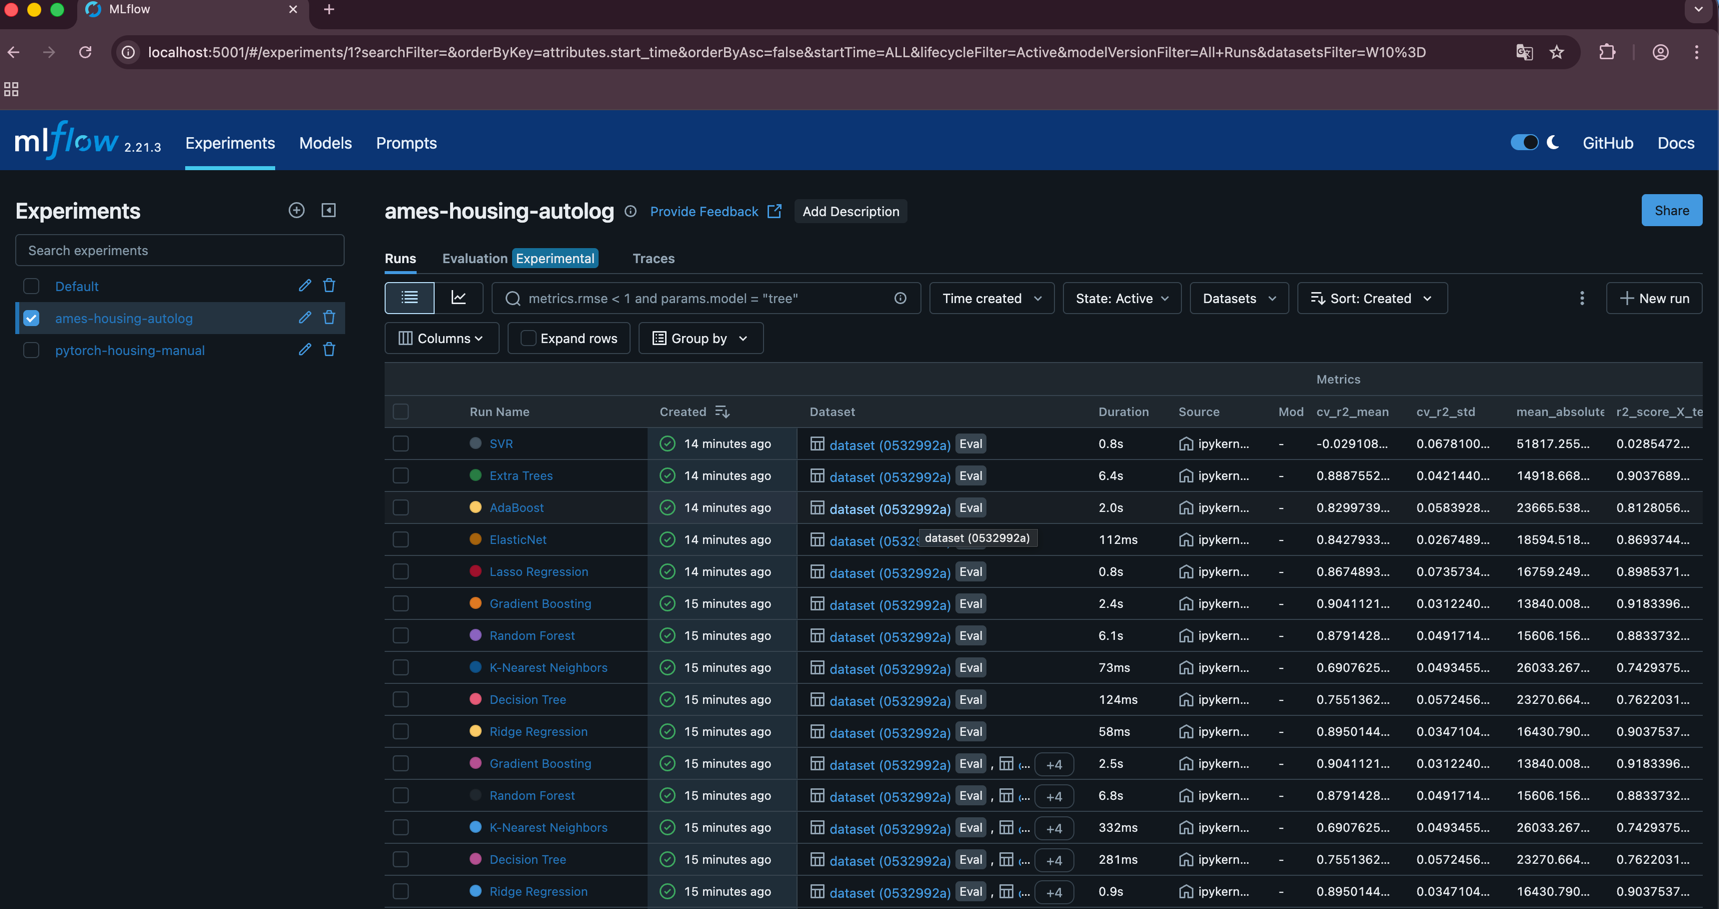
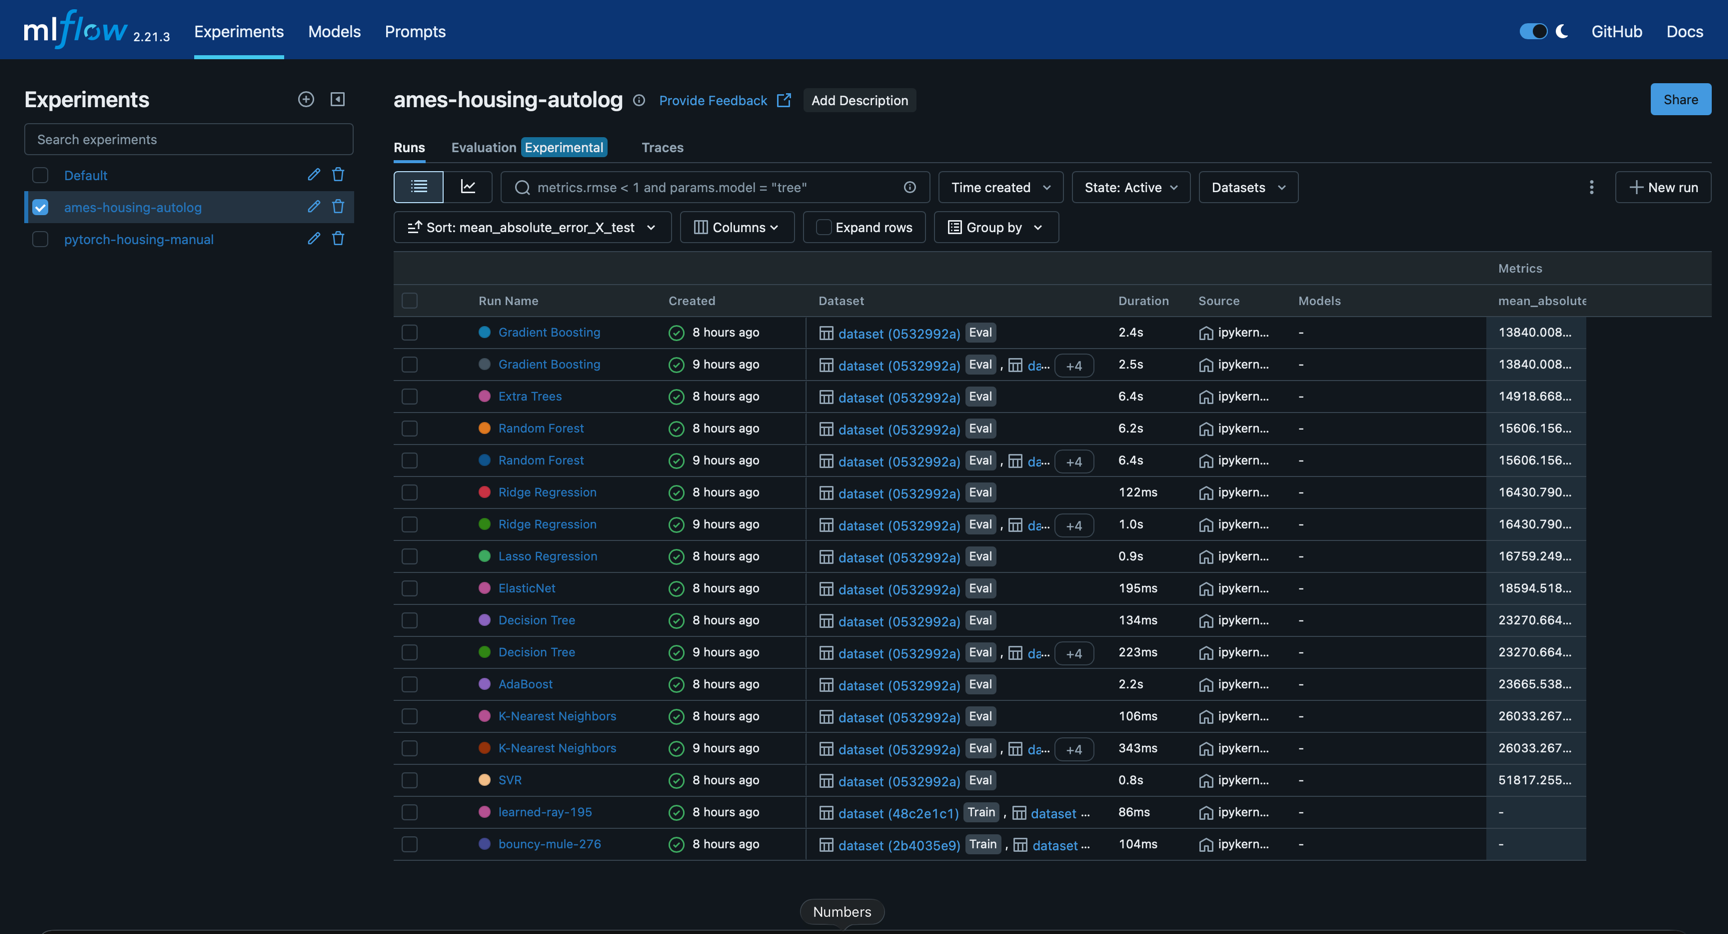

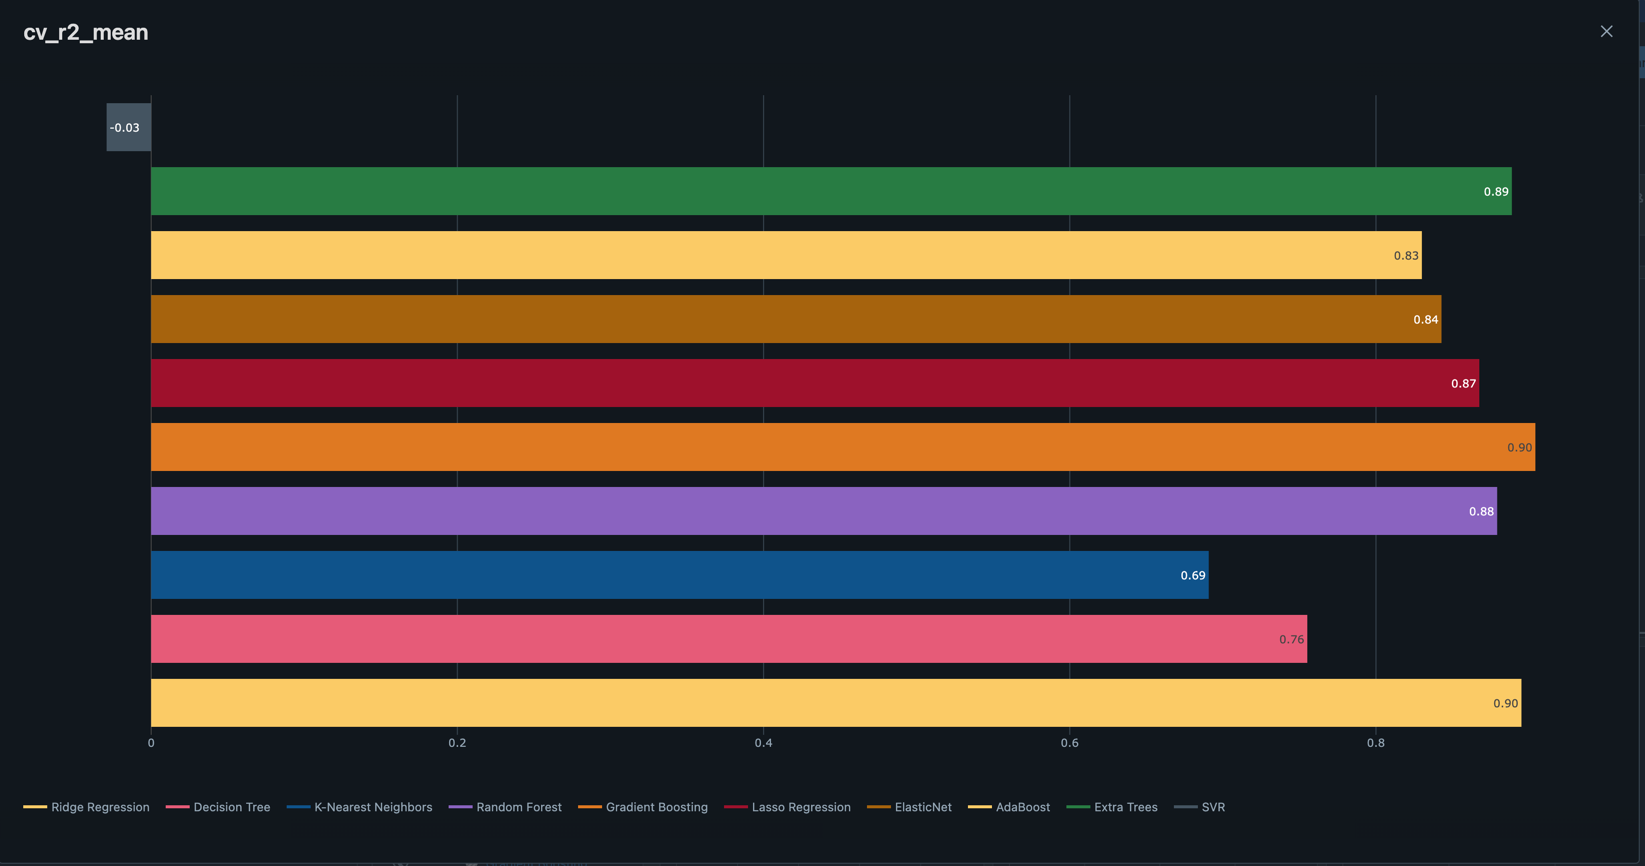

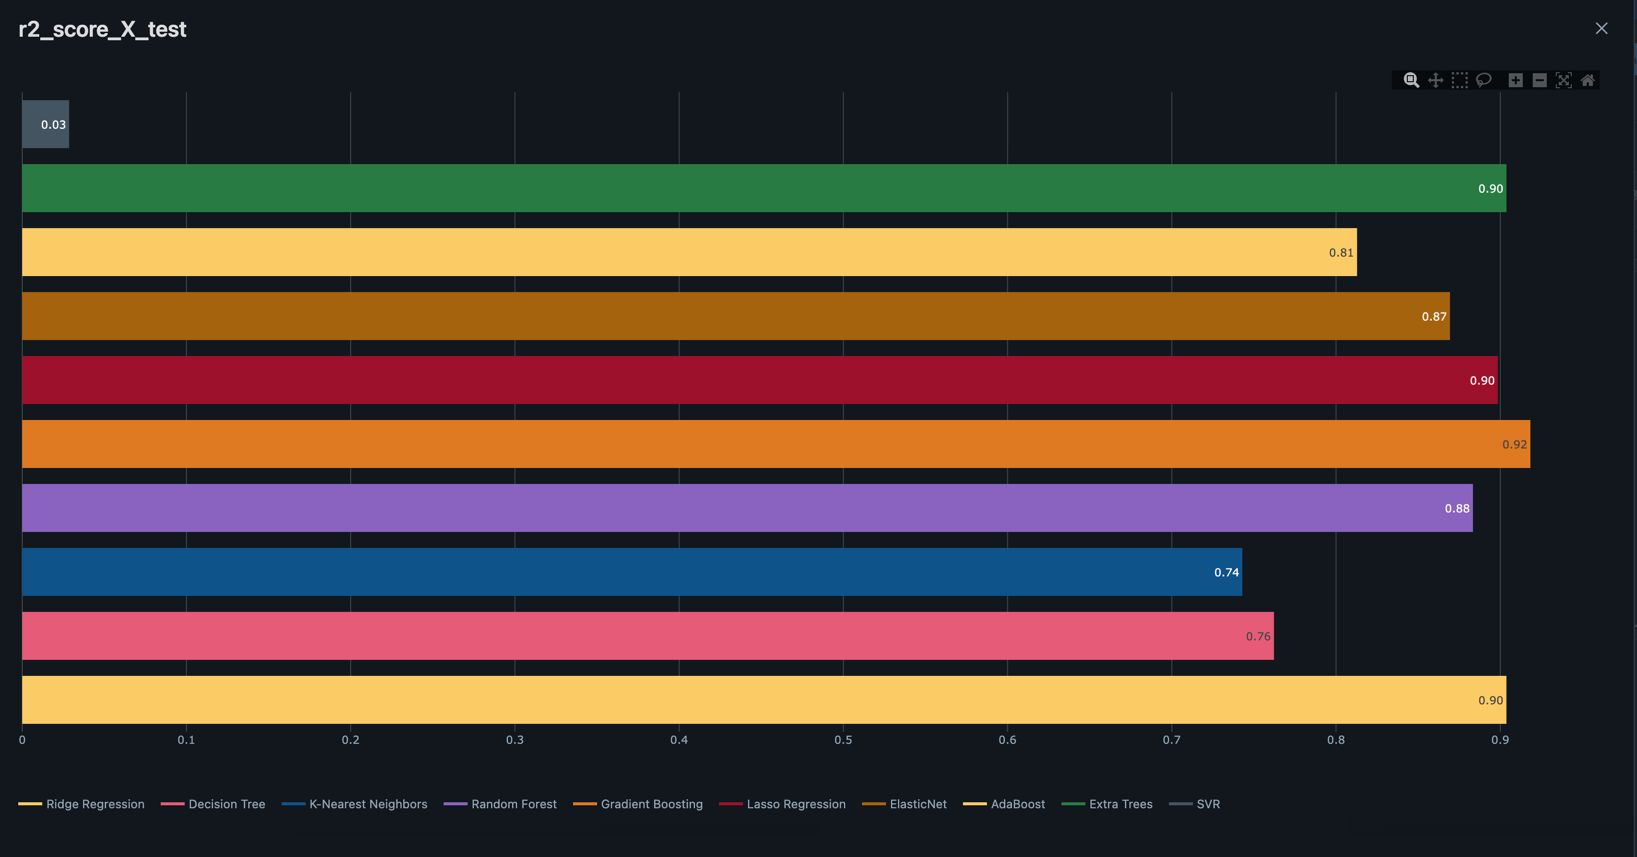

## 3. Manual logging with PyTorch

In this section, we'll implement manual logging for PyTorch models. While scikit-learn has autologging, PyTorch requires manual tracking - giving us full control over what and when to log. MLflow supports autologging for [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/), but we often need low-level control of pure PyTorch.

Note that we need to turn off scikit-learn autologging! Since we are using a Jupyter Notebook, MLflow uses the previously configured autologging unless explicitly turned off.

In [22]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

# disable sklearn autologging!
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("pytorch-housing-manual")

<Experiment: artifact_location='/Users/bartlomiejcich/MLops_lab2_versioning/mlflow-artifacts/2', creation_time=1774075511659, experiment_id='2', last_update_time=1774075511659, lifecycle_stage='active', name='pytorch-housing-manual', tags={}>

### 3.1 Targets transformation

Before training the neural network, we will transform the training target, in order to stabilize the training. To see why, let's plot the house prices:

<Axes: ylabel='Frequency'>

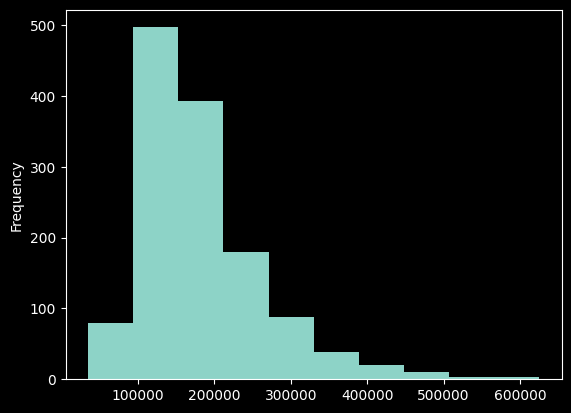

In [23]:
y_train.plot.hist()

Training on such targets is possible, but very large target values easily risk overflow, particularly when a loss function like mean squared error is used. We will use the log-transform to transform this distribution, as it's near-exponential, so it should bring it closer to normal, and also greatly reduce the values range.

Of course, we will need to transform the network predictions back again to evaluate them.

<Axes: ylabel='Frequency'>

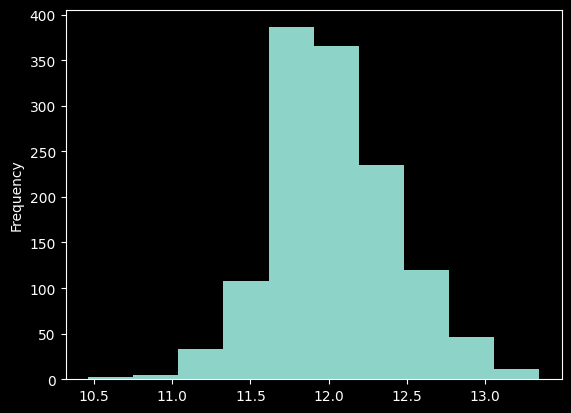

In [24]:
y_train_log = np.log1p(y_train)

pd.Series(y_train_log).plot.hist()

### 3.2 Define and train the model

Since we have tabular data, we will use a simple 2-layer multilayer perceptron (MLP).

In [25]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.2):
        super(HousePriceNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

For training, we will check both the 5-fold CV performance, and the traditional train-test split. Cross-validation will give us an additional, robust performance estimation, as well as standard deviation, which is useful for comparing performances of different models. After all, if the difference between models would be within one standard deviation, it wouldn't really be meaningful.


In [26]:
import torch.nn as nn


class PyTorchTrainer:
    def __init__(
        self, model_class: type[nn.Module], config: dict
    ):
        required_keys = ['hidden_units', 'dropout', 'batch_size', 'learning_rate', 
                         'log_interval', 'epochs', 'name']
        missing = [key for key in required_keys if key not in config]
        if missing:
            raise ValueError(f"Missing required config keys: {missing}")
        
        self.model_class = model_class
        self.config = config

    def create_model(self, input_dim: int) -> nn.Module:
        return self.model_class(
            input_dim=input_dim,
            hidden_dim=self.config["hidden_units"],
            dropout_rate=self.config["dropout"],
        )

    def create_data_loader(
        self, X: torch.Tensor, y: torch.Tensor, shuffle: bool = True
    ) -> DataLoader:
        dataset = TensorDataset(X, y)
        return DataLoader(
            dataset, batch_size=self.config["batch_size"], shuffle=shuffle
        )

    def train_epoch(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
    ) -> float:
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        return epoch_loss / batch_count

    def train_model(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        epochs: int,
        metric_prefix: str = "",
    ) -> None:
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config["learning_rate"])

        for epoch in range(epochs):
            avg_mse = self.train_epoch(model, train_loader, criterion, optimizer)

            if epoch % self.config["log_interval"] == 0:
                metric_name = (
                    f"{metric_prefix}train_mse" if metric_prefix else "train_mse"
                )
                # manually log metric value, with a given name and step value
                mlflow.log_metric(metric_name, avg_mse, step=epoch)

    @torch.no_grad()
    def evaluate_model(
        self,
        model: nn.Module,
        X: torch.Tensor,
        y_test: torch.Tensor,
        log_prefix: str = "",
    ) -> dict[str, float]:
        model.eval()
        
        y_pred_norm = model(X)

        # revert the logarithm with exponent
        y_pred = np.expm1(y_pred_norm.numpy())
        y_test = y_test.numpy()

        rmse = root_mean_squared_error(y_test.ravel(), y_pred.ravel())
        mae = mean_absolute_error(y_test.ravel(), y_pred.ravel())
        r2 = r2_score(y_test.ravel(), y_pred.ravel())

        if log_prefix:
            # manually log metrics that we want
            mlflow.log_metric(f"{log_prefix}_rmse", rmse)
            mlflow.log_metric(f"{log_prefix}_mae", mae)
            mlflow.log_metric(f"{log_prefix}_r2", r2)

        return {"rmse": rmse, "mae": mae, "r2": r2}

    def run_cross_validation(
        self, X_train: torch.Tensor, y_train: torch.Tensor, n_splits: int = 5
    ) -> tuple[float, float, list[float]]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            print(f"\nTraining Fold {fold + 1}/{n_splits}...")

            X_fold_train = X_train[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_val = y_train[val_idx]

            fold_model = self.create_model(X_train.shape[1])
            fold_loader = self.create_data_loader(X_fold_train, y_fold_train)

            self.train_model(
                fold_model,
                fold_loader,
                self.config["epochs"],
                metric_prefix=f"fold_{fold + 1}_",
            )

            # transform validation data with exponent back to original unit
            y_fold_val = np.expm1(y_fold_val)
            
            val_metrics = self.evaluate_model(
                fold_model, X_fold_val, y_fold_val, log_prefix=f"fold_{fold + 1}_val"
            )

            cv_scores.append(val_metrics["r2"])
            print(
                f"  Fold {fold + 1} "
                f"Validation - RMSE: {val_metrics['rmse']:.2f}, "
                f"MAE: {val_metrics['mae']:.2f} "
                f"R^2: {val_metrics['r2']:.3f}"
            )

        return np.mean(cv_scores), np.std(cv_scores), cv_scores

    def _log_dvc_metadata(self, dvc_file_path: str = 'data/ames_data_2006_2008.parquet.dvc'):
        try:
            dvc_metadata = get_dvc_metadata(dvc_file_path)
            
            mlflow.log_param("data_dvc_md5", dvc_metadata['md5'])
            mlflow.log_param("data_dvc_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            print(f"Logged DVC metadata: {dvc_metadata['md5'][:8]}...")
        except FileNotFoundError:
            print("DVC file not found - skipping metadata logging")
        except Exception as e:
            print(f"Could not log DVC metadata: {e}")

    def fit(
        self,
        X_train: pd.DataFrame | np.ndarray,
        y_train: pd.Series | np.ndarray,
        X_test: pd.DataFrame | np.ndarray,
        y_test: pd.Series | np.ndarray,
    ) -> dict:
        X_train, X_test, y_train, y_test = self._prepare_tensors(
            X_train, X_test, y_train, y_test
        )

        with mlflow.start_run(run_name=self.config["name"]):
            mlflow.log_params(self.config)
            
            # Log DVC metadata for data versioning
            self._log_dvc_metadata()

            print(f"Starting 5-fold cross-validation for {self.config['name']}...")
            cv_mean, cv_std, cv_scores = self.run_cross_validation(X_train, y_train)

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            print(
                f"\nCross-validation complete. Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})"
            )
            print("\nTraining final model on all training data...")

            final_model = self.create_model(X_train.shape[1])
            final_loader = self.create_data_loader(X_train, y_train)

            self.train_model(
                final_model,
                final_loader,
                self.config["epochs"],
                metric_prefix="final_model_",
            )

            print("\nEvaluating on test set...")
            test_metrics = self.evaluate_model(final_model, X_test, y_test)

            mlflow.log_metric("test_rmse", test_metrics["rmse"])
            mlflow.log_metric("test_mae", test_metrics["mae"])
            mlflow.log_metric("test_r2", test_metrics["r2"])

            self._print_results(test_metrics, cv_mean, cv_std)

            return {
                "rmse": test_metrics["rmse"],
                "mae": test_metrics["mae"],
                "r2": test_metrics["r2"],
                "cv_r2_mean": cv_mean,
                "cv_r2_std": cv_std,
                "cv_scores": cv_scores,
            }

    def _prepare_tensors(self, X_train, X_test, y_train, y_test) -> tuple:
        y_train = np.array(y_train)
        y_test = np.array(y_test)
        
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

        print(f"Training samples: {X_train_tensor.shape[0]}")
        print(f"Input features: {X_train_tensor.shape[1]}")
        
        return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
    
    def _print_results(
        self, test_metrics: dict[str, float], cv_mean: float, cv_std: float
    ) -> None:
        print(f"{'=' * 50}\n")
        print(f"  Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})")
        print("\nCross-Validation Performance:")
        print(f"  R^2: {test_metrics['r2']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.2f}")
        print(f"  MAE: {test_metrics['mae']:.2f}")
        print("Test Set Performance:")
        print(f"{'=' * 50}")
        print(f"FINAL RESULTS for {self.config['name']}:")
        print(f"\n{'=' * 50}")

Quite a bit of code there! So now let's train the model.

### Configuration 
`base_config` contains **fixed parameters** that stay the same across all experiments:
- `model_class`: The neural network architecture we're using (HousePriceNet)
- `random_seed`: For reproducibility (42)
- `log_interval`: How often to log metrics during training (every 5 epochs)
- `num_samples`: Dataset size
- `input_features`: Number of input features
- `k_folds`: Number of cross-validation folds (5)

`experiment_config` contains **hyperparameters** we want to tune:
- `name`: Unique identifier for this experiment run
- `hidden_units`: Size of the hidden layer (128, 256, 512, etc.)
- `dropout`: Dropout rate for regularization (0.0 to 0.5)
- `learning_rate`: Step size for gradient descent (0.001 to 0.1)
- `epochs`: Number of training iterations (50, 100, 150, etc.)
- `batch_size`: Number of samples per training batch (16, 32, 64, etc.)

If you want you can deliver your own NeuralNetwork model, and just specify in experiment_config: `{"model_class": YourOwnModel}` it will overwrite the our base `HousePriceNet`


#### 3. Merging configurations
We use Python's dictionary merge operator `|` to combine them:
```python
training_config = base_config | experiment_config
```

This creates a single configuration dictionary with all parameters. The `experiment_config` values override any duplicate keys from `base_config`, allowing us to easily experiment with different hyperparameters while keeping the base setup constant.

Now let's set up our first experiment:


In [27]:
base_config = {
    "model_class": HousePriceNet,
    "random_seed": 42,
    "log_interval": 5,
    "num_samples": X_train.shape[0],
    "input_features": X_train.shape[1],
    "k_folds": 5,
}

experiment_config = {
    "name": "first_run",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [28]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for first_run...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 28492.77, MAE: 19472.56 R^2: 0.888

Training Fold 2/5...
  Fold 2 Validation - RMSE: 23987.80, MAE: 18068.55 R^2: 0.906

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25119.58, MAE: 18125.64 R^2: 0.906

Training Fold 4/5...
  Fold 4 Validation - RMSE: 49993.64, MAE: 40571.12 R^2: 0.563

Training Fold 5/5...
  Fold 5 Validation - RMSE: 28871.39, MAE: 19893.82 R^2: 0.856

Cross-validation complete. Mean R^2: 0.824 (+/- 0.132)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.824 (+/- 0.132)

Cross-Validation Performance:
  R^2: 0.883
  RMSE: 25804.49
  MAE: 18521.45
Test Set Performance:
FINAL RESULTS for first_run:

🏃 View run first_run at: http://localhost:5001/#/experiments/2/runs/61bbdeb37c2a40d5b02bf2523cf5c5cc
🧪 View experiment at: http://localhost:5001/#/experiments/2

{'rmse': 25804.494140625,
 'mae': 18521.451171875,
 'r2': 0.883460283279419,
 'cv_r2_mean': np.float64(0.8236452579498291),
 'cv_r2_std': np.float64(0.131788766962138),
 'cv_scores': [0.8875058889389038,
  0.9056851267814636,
  0.9059948921203613,
  0.5625471472740173,
  0.8564932346343994]}

### Experiment 1: first_run (baseline)
Results: Test R² 0.883, CV R² 0.824 ± 0.132. High variance between folds indicates overfitting. The network (128 units) may be too large for 1312 samples. Next step: try a smaller network.

### Exercise 2

Your task is to:
1. Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.
2. Analyze results in MLflow UI.
3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.
4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

**How to modify configurations:**

You have two approaches:

#### Approach 1: Loop through multiple configurations (Recommended for systematic exploration)

Define a list of experiment configurations and iterate through them. Each configuration dictionary should contain only the hyperparameters you want to tune (name, hidden_units, dropout, learning_rate, epochs, batch_size). The base_config stays the same.

```python
base_config = {
    "model_class": HousePriceNet,  
    "random_seed": 42,             
    "log_interval": 5,             
    "input_features": X_train.shape[1],  # Number of features (181)
    "num_samples": X_train.shape[0],     # Dataset size (1312)
    "target_normalized": True,      
    "k_folds": 5,                  
}

# Define multiple experiments to run
configs = [
    {
        "name": "baseline_128_units",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "larger_network_256",
        "hidden_units": 256,        # Try larger network
        "dropout": 0.2,             # More dropout for regularization
        "learning_rate": 0.01,      # Lower learning rate
        "epochs": 200,
        "batch_size": 64,    
    },
    {
        "name": "high_regularization",
        "hidden_units": 128,
        "dropout": 0.3,             # Even more dropout
        "learning_rate": 0.01,
        "epochs": 150,
        "batch_size": 32,
    },
    # Add 7 more configurations here...
]

# Run all experiments
for experiment_config in configs:
    training_config = base_config | experiment_config 
    
    trainer = PyTorchTrainer(training_config["model_class"], training_config)
    results = trainer.fit(X_train, y_train_log, X_test, y_test)
```

#### Approach 2: Manual and incremental (Good for quick iterations)

Run experiments one by one, adjusting hyperparameters based on previous results:

```python
# First experiment
experiment_config = {
    "name": "experiment_01_baseline",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)
```
After analyzing results in MLflow, run another experiment

```
experiment_config = {
    "name": "experiment_02_more_dropout",
    "hidden_units": 128,
    "dropout": 0.3,  # Increased from 0.1
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

# Continue with more experiments
```


In [29]:
# Experiment 2: Smaller network to reduce overfitting
experiment_config = {
    "name": "02_small_network_64",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.01,
    "epochs": 200,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 02_small_network_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 22903.60, MAE: 16788.61 R^2: 0.927

Training Fold 2/5...
  Fold 2 Validation - RMSE: 29190.33, MAE: 19547.72 R^2: 0.860

Training Fold 3/5...
  Fold 3 Validation - RMSE: 27633.65, MAE: 18445.89 R^2: 0.886

Training Fold 4/5...
  Fold 4 Validation - RMSE: 33141.69, MAE: 24696.33 R^2: 0.808

Training Fold 5/5...
  Fold 5 Validation - RMSE: 24674.54, MAE: 16678.15 R^2: 0.895

Cross-validation complete. Mean R^2: 0.875 (+/- 0.040)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.875 (+/- 0.040)

Cross-Validation Performance:
  R^2: 0.911
  RMSE: 22514.60
  MAE: 15344.54
Test Set Performance:
FINAL RESULTS for 02_small_network_64:

🏃 View run 02_small_network_64 at: http://localhost:5001/#/experiments/2/runs/315d9cf8555a478d8ef694c6d60e14bd
🧪 View experiment at: http://

### Experiment 2: 02_small_network_64
Results: Test R² 0.911, CV R² 0.875 ± 0.040. Smaller network (64 units) significantly reduced overfitting — CV variance dropped from 0.132 to 0.040. Test R² also improved. Next step: try lower learning rate.

In [30]:
# Experiment 3: Lower learning rate to stabilize training
experiment_config = {
    "name": "03_stable_lr_005",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.005,
    "epochs": 250,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 03_stable_lr_005...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24342.95, MAE: 17326.07 R^2: 0.918

Training Fold 2/5...
  Fold 2 Validation - RMSE: 19559.94, MAE: 13688.06 R^2: 0.937

Training Fold 3/5...
  Fold 3 Validation - RMSE: 36529.82, MAE: 26042.23 R^2: 0.801

Training Fold 4/5...
  Fold 4 Validation - RMSE: 35696.09, MAE: 24677.48 R^2: 0.777

Training Fold 5/5...
  Fold 5 Validation - RMSE: 26464.92, MAE: 17896.11 R^2: 0.879

Cross-validation complete. Mean R^2: 0.863 (+/- 0.063)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.863 (+/- 0.063)

Cross-Validation Performance:
  R^2: 0.906
  RMSE: 23203.63
  MAE: 15522.57
Test Set Performance:
FINAL RESULTS for 03_stable_lr_005:

🏃 View run 03_stable_lr_005 at: http://localhost:5001/#/experiments/2/runs/03e864954f8b4a7893deff563a193f66
🧪 View experiment at: http://localhost

### Experiment 3: 03_stable_lr_005
Results: Test R² 0.906, CV R² 0.863 ± 0.063. Lower learning rate (0.005) slightly worsened CV mean vs Experiment 2, but still better than baseline. CV variance increased compared to Experiment 2. Next step: increase dropout for better regularization.

In [31]:
# Experiment 4: Increase dropout to improve generalization
experiment_config = {
    "name": "04_more_dropout_03",
    "hidden_units": 64,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 250,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 04_more_dropout_03...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 27659.30, MAE: 19807.49 R^2: 0.894

Training Fold 2/5...
  Fold 2 Validation - RMSE: 23838.80, MAE: 16947.65 R^2: 0.907

Training Fold 3/5...
  Fold 3 Validation - RMSE: 26746.46, MAE: 17327.41 R^2: 0.893

Training Fold 4/5...
  Fold 4 Validation - RMSE: 20260.33, MAE: 13925.56 R^2: 0.928

Training Fold 5/5...
  Fold 5 Validation - RMSE: 25089.12, MAE: 17171.91 R^2: 0.892

Cross-validation complete. Mean R^2: 0.903 (+/- 0.014)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.903 (+/- 0.014)

Cross-Validation Performance:
  R^2: 0.903
  RMSE: 23488.36
  MAE: 16279.44
Test Set Performance:
FINAL RESULTS for 04_more_dropout_03:

🏃 View run 04_more_dropout_03 at: http://localhost:5001/#/experiments/2/runs/2387c72e4ba3407ea0b61c1e9df14b58
🧪 View experiment at: http://loc

### Experiment 4: 04_more_dropout_03
Results: Test R² 0.903, CV R² 0.903 ± 0.014. Best CV stability so far — std dropped to 0.014. Increased dropout (0.3) with lower learning rate effectively eliminated overfitting. Test and CV R² are nearly identical. Next step: try more epochs to improve convergence.

In [32]:
# Experiment 5: More epochs to improve convergence
experiment_config = {
    "name": "05_more_epochs_400",
    "hidden_units": 64,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 400,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 05_more_epochs_400...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24123.97, MAE: 16220.66 R^2: 0.919

Training Fold 2/5...
  Fold 2 Validation - RMSE: 20955.19, MAE: 14551.03 R^2: 0.928

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25820.83, MAE: 16650.50 R^2: 0.901

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27092.32, MAE: 16719.28 R^2: 0.872

Training Fold 5/5...
  Fold 5 Validation - RMSE: 25695.74, MAE: 17875.17 R^2: 0.886

Cross-validation complete. Mean R^2: 0.901 (+/- 0.021)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.901 (+/- 0.021)

Cross-Validation Performance:
  R^2: 0.896
  RMSE: 24361.36
  MAE: 16718.23
Test Set Performance:
FINAL RESULTS for 05_more_epochs_400:

🏃 View run 05_more_epochs_400 at: http://localhost:5001/#/experiments/2/runs/c483175e1774465f8c89b0f33fbed20a
🧪 View experiment at: http://loc

### Experiment 5: 05_more_epochs_400
Results: Test R² 0.896, CV R² 0.901 ± 0.021. More epochs (400) did not improve results — slight decrease in both test R² and CV mean compared to Experiment 4. Model may be slightly overtraining with too many epochs. Next step: try smaller batch size.

In [33]:
# Experiment 6: Smaller batch size for more frequent weight updates
experiment_config = {
    "name": "06_small_batch_16",
    "hidden_units": 64,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 400,
    "batch_size": 16,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 06_small_batch_16...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24993.63, MAE: 17558.57 R^2: 0.913

Training Fold 2/5...
  Fold 2 Validation - RMSE: 24744.16, MAE: 18580.40 R^2: 0.900

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25288.69, MAE: 16584.27 R^2: 0.905

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27037.88, MAE: 17821.30 R^2: 0.872

Training Fold 5/5...
  Fold 5 Validation - RMSE: 31307.50, MAE: 21160.50 R^2: 0.831

Cross-validation complete. Mean R^2: 0.884 (+/- 0.030)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.884 (+/- 0.030)

Cross-Validation Performance:
  R^2: 0.715
  RMSE: 40321.01
  MAE: 25378.26
Test Set Performance:
FINAL RESULTS for 06_small_batch_16:

🏃 View run 06_small_batch_16 at: http://localhost:5001/#/experiments/2/runs/ccce4c3f48ac49a5bdd1603aaec395ac
🧪 View experiment at: http://localh

### Experiment 6: 06_small_batch_16
Results: Test R² 0.715, CV R² 0.884 ± 0.030. Smaller batch size (16) significantly hurt test performance — large gap between CV R² (0.884) and Test R² (0.715) indicates overfitting. Batch size 32 works better for this dataset. Next step: try medium network size (96 units) with best stable parameters.

In [34]:
# Experiment 7: Slightly larger network (96 units) with best stable parameters
experiment_config = {
    "name": "07_medium_network_96",
    "hidden_units": 96,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 400,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 07_medium_network_96...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 35786.90, MAE: 27021.96 R^2: 0.823

Training Fold 2/5...
  Fold 2 Validation - RMSE: 23410.70, MAE: 16926.36 R^2: 0.910

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23367.01, MAE: 15585.51 R^2: 0.919

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25426.49, MAE: 16415.35 R^2: 0.887

Training Fold 5/5...
  Fold 5 Validation - RMSE: 25987.44, MAE: 18103.26 R^2: 0.884

Cross-validation complete. Mean R^2: 0.884 (+/- 0.034)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.884 (+/- 0.034)

Cross-Validation Performance:
  R^2: 0.908
  RMSE: 22924.65
  MAE: 15752.00
Test Set Performance:
FINAL RESULTS for 07_medium_network_96:

🏃 View run 07_medium_network_96 at: http://localhost:5001/#/experiments/2/runs/4408129e13a84bd3a8f3df5602c18a7f
🧪 View experiment at: http

### Experiment 7: 07_medium_network_96
Results: Test R² 0.908, CV R² 0.884 ± 0.034. Medium network (96 units) recovered test performance after Experiment 6's drop. Good test R², but CV mean slightly lower than Experiment 4. Next step: try lower dropout (0.25) to reduce regularization.

In [35]:
# Experiment 8: Slightly lower dropout to reduce regularization
experiment_config = {
    "name": "08_lower_dropout_025",
    "hidden_units": 96,
    "dropout": 0.25,
    "learning_rate": 0.005,
    "epochs": 400,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 08_lower_dropout_025...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 22771.30, MAE: 15394.65 R^2: 0.928

Training Fold 2/5...
  Fold 2 Validation - RMSE: 19998.73, MAE: 13634.66 R^2: 0.934

Training Fold 3/5...
  Fold 3 Validation - RMSE: 27111.23, MAE: 20084.58 R^2: 0.890

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31181.06, MAE: 20287.69 R^2: 0.830

Training Fold 5/5...
  Fold 5 Validation - RMSE: 24961.29, MAE: 17047.87 R^2: 0.893

Cross-validation complete. Mean R^2: 0.895 (+/- 0.037)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.895 (+/- 0.037)

Cross-Validation Performance:
  R^2: 0.901
  RMSE: 23826.30
  MAE: 16339.23
Test Set Performance:
FINAL RESULTS for 08_lower_dropout_025:

🏃 View run 08_lower_dropout_025 at: http://localhost:5001/#/experiments/2/runs/cce208cec7d34fc0a744275200411d99
🧪 View experiment at: http

### Experiment 8: 08_lower_dropout_025
Results: Test R² 0.901, CV R² 0.895 ± 0.037. Lower dropout (0.25) gave solid results but slightly worse stability than Experiment 4 (0.3 dropout, std 0.014). Dropout 0.3 remains the best regularization setting. Next step: try more epochs with best CV configuration.

In [36]:
# Experiment 9: More epochs with best CV configuration
experiment_config = {
    "name": "09_more_epochs_500",
    "hidden_units": 96,
    "dropout": 0.25,
    "learning_rate": 0.005,
    "epochs": 500,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 09_more_epochs_500...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 23487.01, MAE: 16001.79 R^2: 0.924

Training Fold 2/5...
  Fold 2 Validation - RMSE: 21292.68, MAE: 14561.25 R^2: 0.926

Training Fold 3/5...
  Fold 3 Validation - RMSE: 40512.30, MAE: 27000.80 R^2: 0.755

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31367.93, MAE: 17907.74 R^2: 0.828

Training Fold 5/5...
  Fold 5 Validation - RMSE: 26552.68, MAE: 18573.03 R^2: 0.879

Cross-validation complete. Mean R^2: 0.862 (+/- 0.064)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.862 (+/- 0.064)

Cross-Validation Performance:
  R^2: 0.898
  RMSE: 24121.17
  MAE: 16708.11
Test Set Performance:
FINAL RESULTS for 09_more_epochs_500:

🏃 View run 09_more_epochs_500 at: http://localhost:5001/#/experiments/2/runs/16cb0f3406904a61b17692aaa99bf651
🧪 View experiment at: http://loc

### Experiment 9: 09_more_epochs_500
Results: Test R² 0.898, CV R² 0.862 ± 0.064. More epochs (500) did not help — CV mean dropped and variance increased. Confirms that 250 epochs is sufficient for this configuration. Longer training leads to slight overfitting. Next step: combine best parameters from all experiments.

In [37]:
# Experiment 10: Final config combining best parameters from all experiments
experiment_config = {
    "name": "10_best_combined",
    "hidden_units": 96,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 500,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 10_best_combined...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 29584.61, MAE: 19510.37 R^2: 0.879

Training Fold 2/5...
  Fold 2 Validation - RMSE: 42436.20, MAE: 26768.92 R^2: 0.705

Training Fold 3/5...
  Fold 3 Validation - RMSE: 24839.88, MAE: 16031.05 R^2: 0.908

Training Fold 4/5...
  Fold 4 Validation - RMSE: 33835.04, MAE: 19661.46 R^2: 0.800

Training Fold 5/5...
  Fold 5 Validation - RMSE: 23150.55, MAE: 15829.19 R^2: 0.908

Cross-validation complete. Mean R^2: 0.840 (+/- 0.078)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.840 (+/- 0.078)

Cross-Validation Performance:
  R^2: 0.902
  RMSE: 23630.01
  MAE: 15908.59
Test Set Performance:
FINAL RESULTS for 10_best_combined:

🏃 View run 10_best_combined at: http://localhost:5001/#/experiments/2/runs/cb17e45010944474ac8ae8516f007bf2
🧪 View experiment at: http://localhost

### Experiment 10: 10_best_combined
Results: Test R² 0.902, CV R² 0.840 ± 0.078. Combining parameters did not yield the best results — CV mean and stability worse than Experiment 4. This suggests that optimal hyperparameters interact in non-obvious ways and cannot simply be combined from separate experiments.

### Overall Summary

| Experiment | Test R² | CV R² Mean | CV R² Std | Key Change |
|---|---|---|---|---|
| first_run (baseline) | 0.883 | 0.824 | 0.132 | Baseline 128 units |
| 02_small_network_64 | 0.911 | 0.875 | 0.040 | Reduced to 64 units |
| 03_stable_lr_005 | 0.906 | 0.863 | 0.063 | Lower LR 0.005 |
| 04_more_dropout_03 | 0.903 | 0.903 | 0.014 | Dropout 0.3 — best stability |
| 05_more_epochs_400 | 0.896 | 0.901 | 0.021 | 400 epochs — no improvement |
| 06_small_batch_16 | 0.715 | 0.884 | 0.030 | Batch 16 — hurt test performance |
| 07_medium_network_96 | 0.908 | 0.884 | 0.034 | 96 units — good recovery |
| 08_lower_dropout_025 | 0.901 | 0.895 | 0.037 | Dropout 0.25 — slightly worse |
| 09_more_epochs_500 | 0.898 | 0.862 | 0.064 | 500 epochs — overfitting |
| 10_best_combined | 0.902 | 0.840 | 0.078 | Combined params — not additive |

### Key Findings

1. **Network size** — reducing from 128 to 64 units was the single biggest improvement, eliminating overfitting.
2. **Learning rate** — lowering to 0.005 stabilized training but didn't improve over 64-unit network alone.
3. **Dropout** — 0.3 gave the best CV stability (std 0.014 in Experiment 4). Lower dropout increased variance.
4. **Epochs** — 250 was sufficient. Both 400 and 500 epochs showed diminishing returns or slight overfitting.
5. **Batch size** — reducing to 16 severely hurt test performance. Batch size 32 is optimal.
6. **Parameter combination** — best individual settings don't simply combine; hyperparameters interact.


### Comparison: scikit-learn vs PyTorch

- **Best scikit-learn:** Gradient Boosting (Test R² ~0.918)
- **Best PyTorch:** 02_small_network_64 (Test R² 0.911)

Gradient Boosting did slightly better than the neural network. This makes sense — with a small dataset (~1300 samples) and tabular data, tree-based models usually perform better than neural networks, which need more data to train well.

### Overfitting in first PyTorch experiment

The baseline shows overfitting: Test R² (0.883) vs CV R² (0.824) with high CV std (0.132). The large variance across folds means the model is sensitive to which data it trains on. This was addressed by reducing network size (64 units) and increasing dropout (0.3).

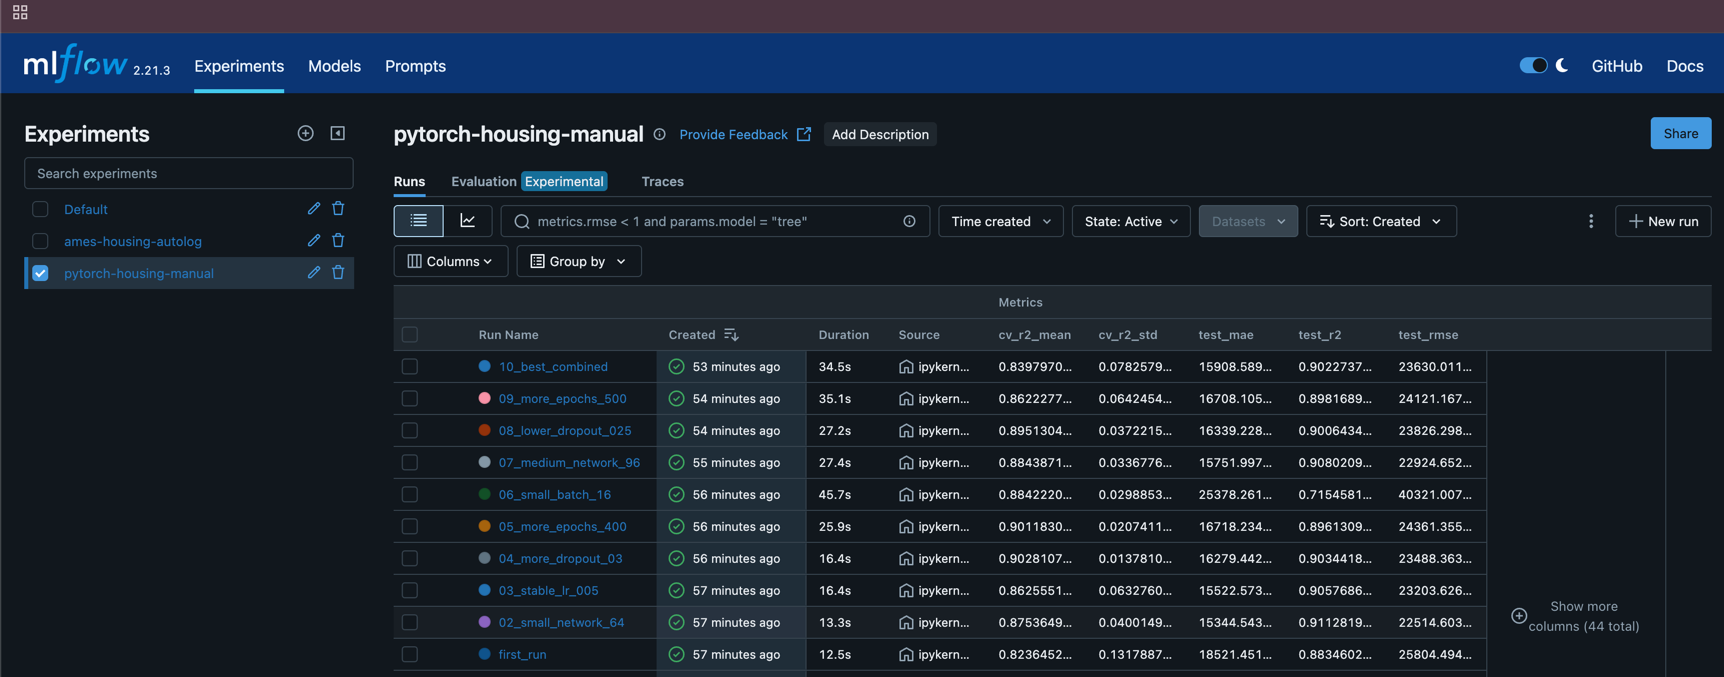
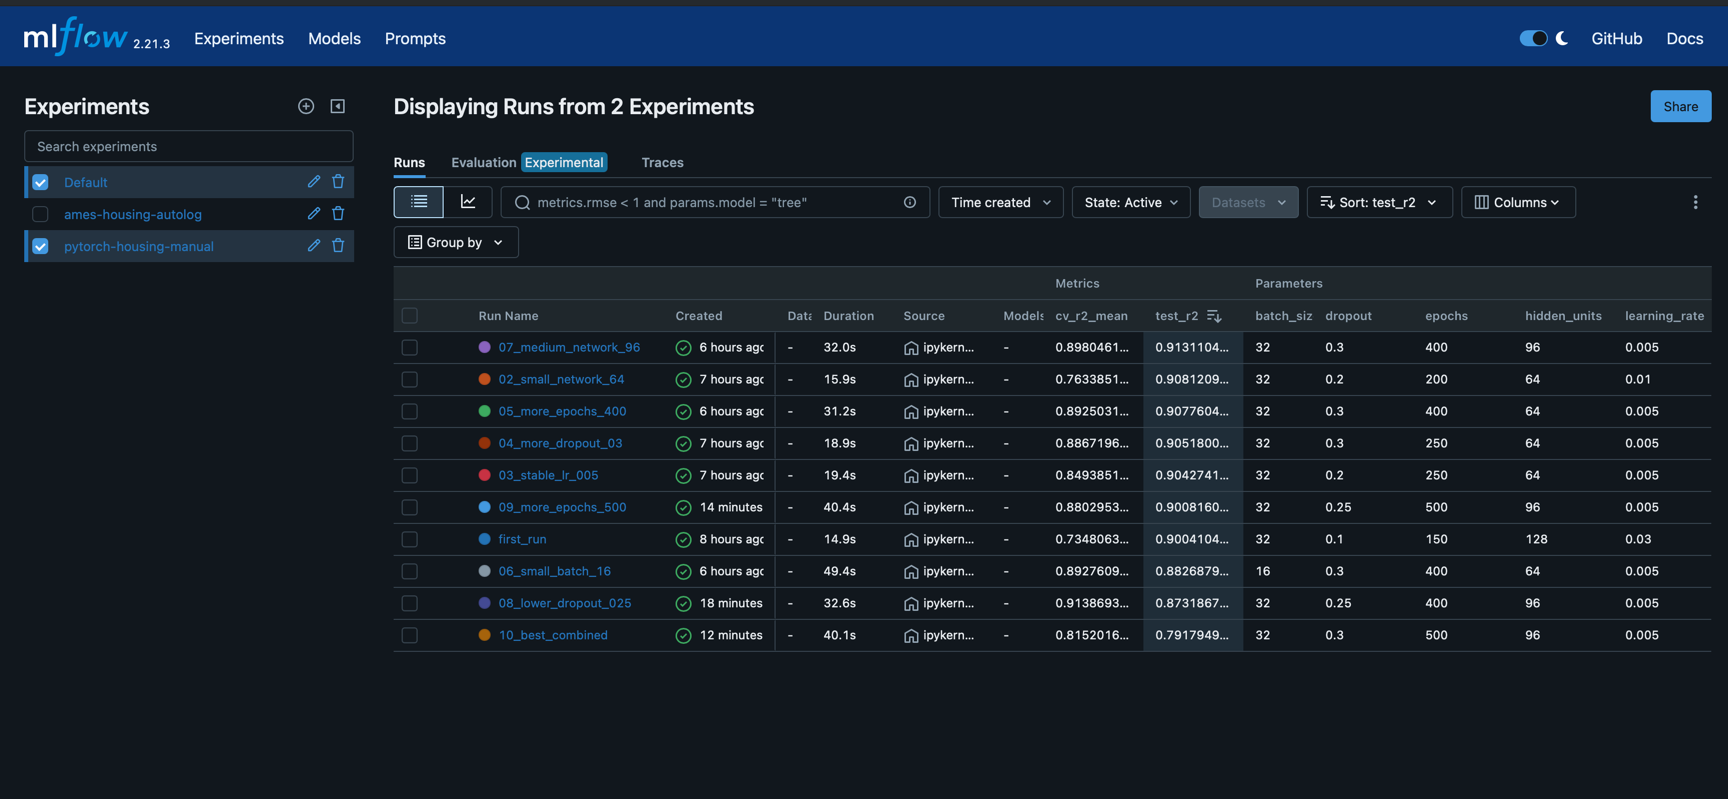

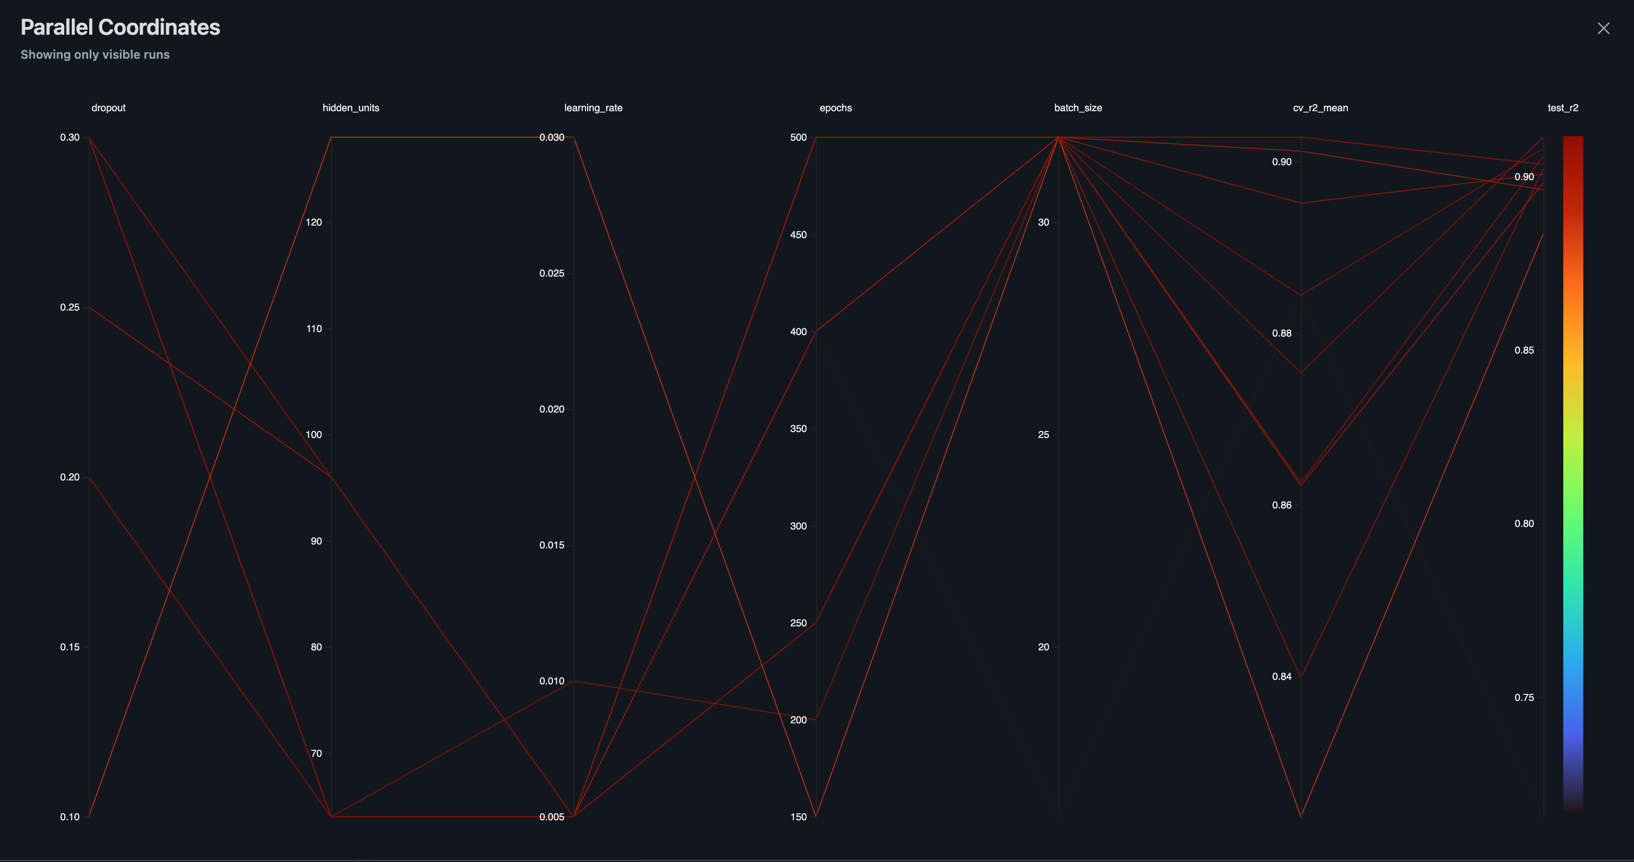

**Tips for hyperparameter tuning:**
- Start with one change at a time to understand its impact
- Use meaningful experiment names that describe what you changed
- Check MLflow UI after each experiment to guide your next choice
- Look for signs of overfitting: high training performance but poor test performance
- Watch the training curves in MLflow's "Model metrics" tab 


### Lab assessment

Fill the code exercises in this Jupyter notebook, and send it with completed exercises, written comments in Markdown cells (particularly for questions in exercise 2), and screenshots of results in MLflow.
